In [35]:
import numpy as np
import matplotlib.pyplot as plt

%load_ext autoreload
%autoreload 2

import sys
import os
sys.path.append(os.path.abspath('..'))
import lib_plot


The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


Eigenvalues = [-0.83767458 -0.3821689   0.2356261   0.78506003]


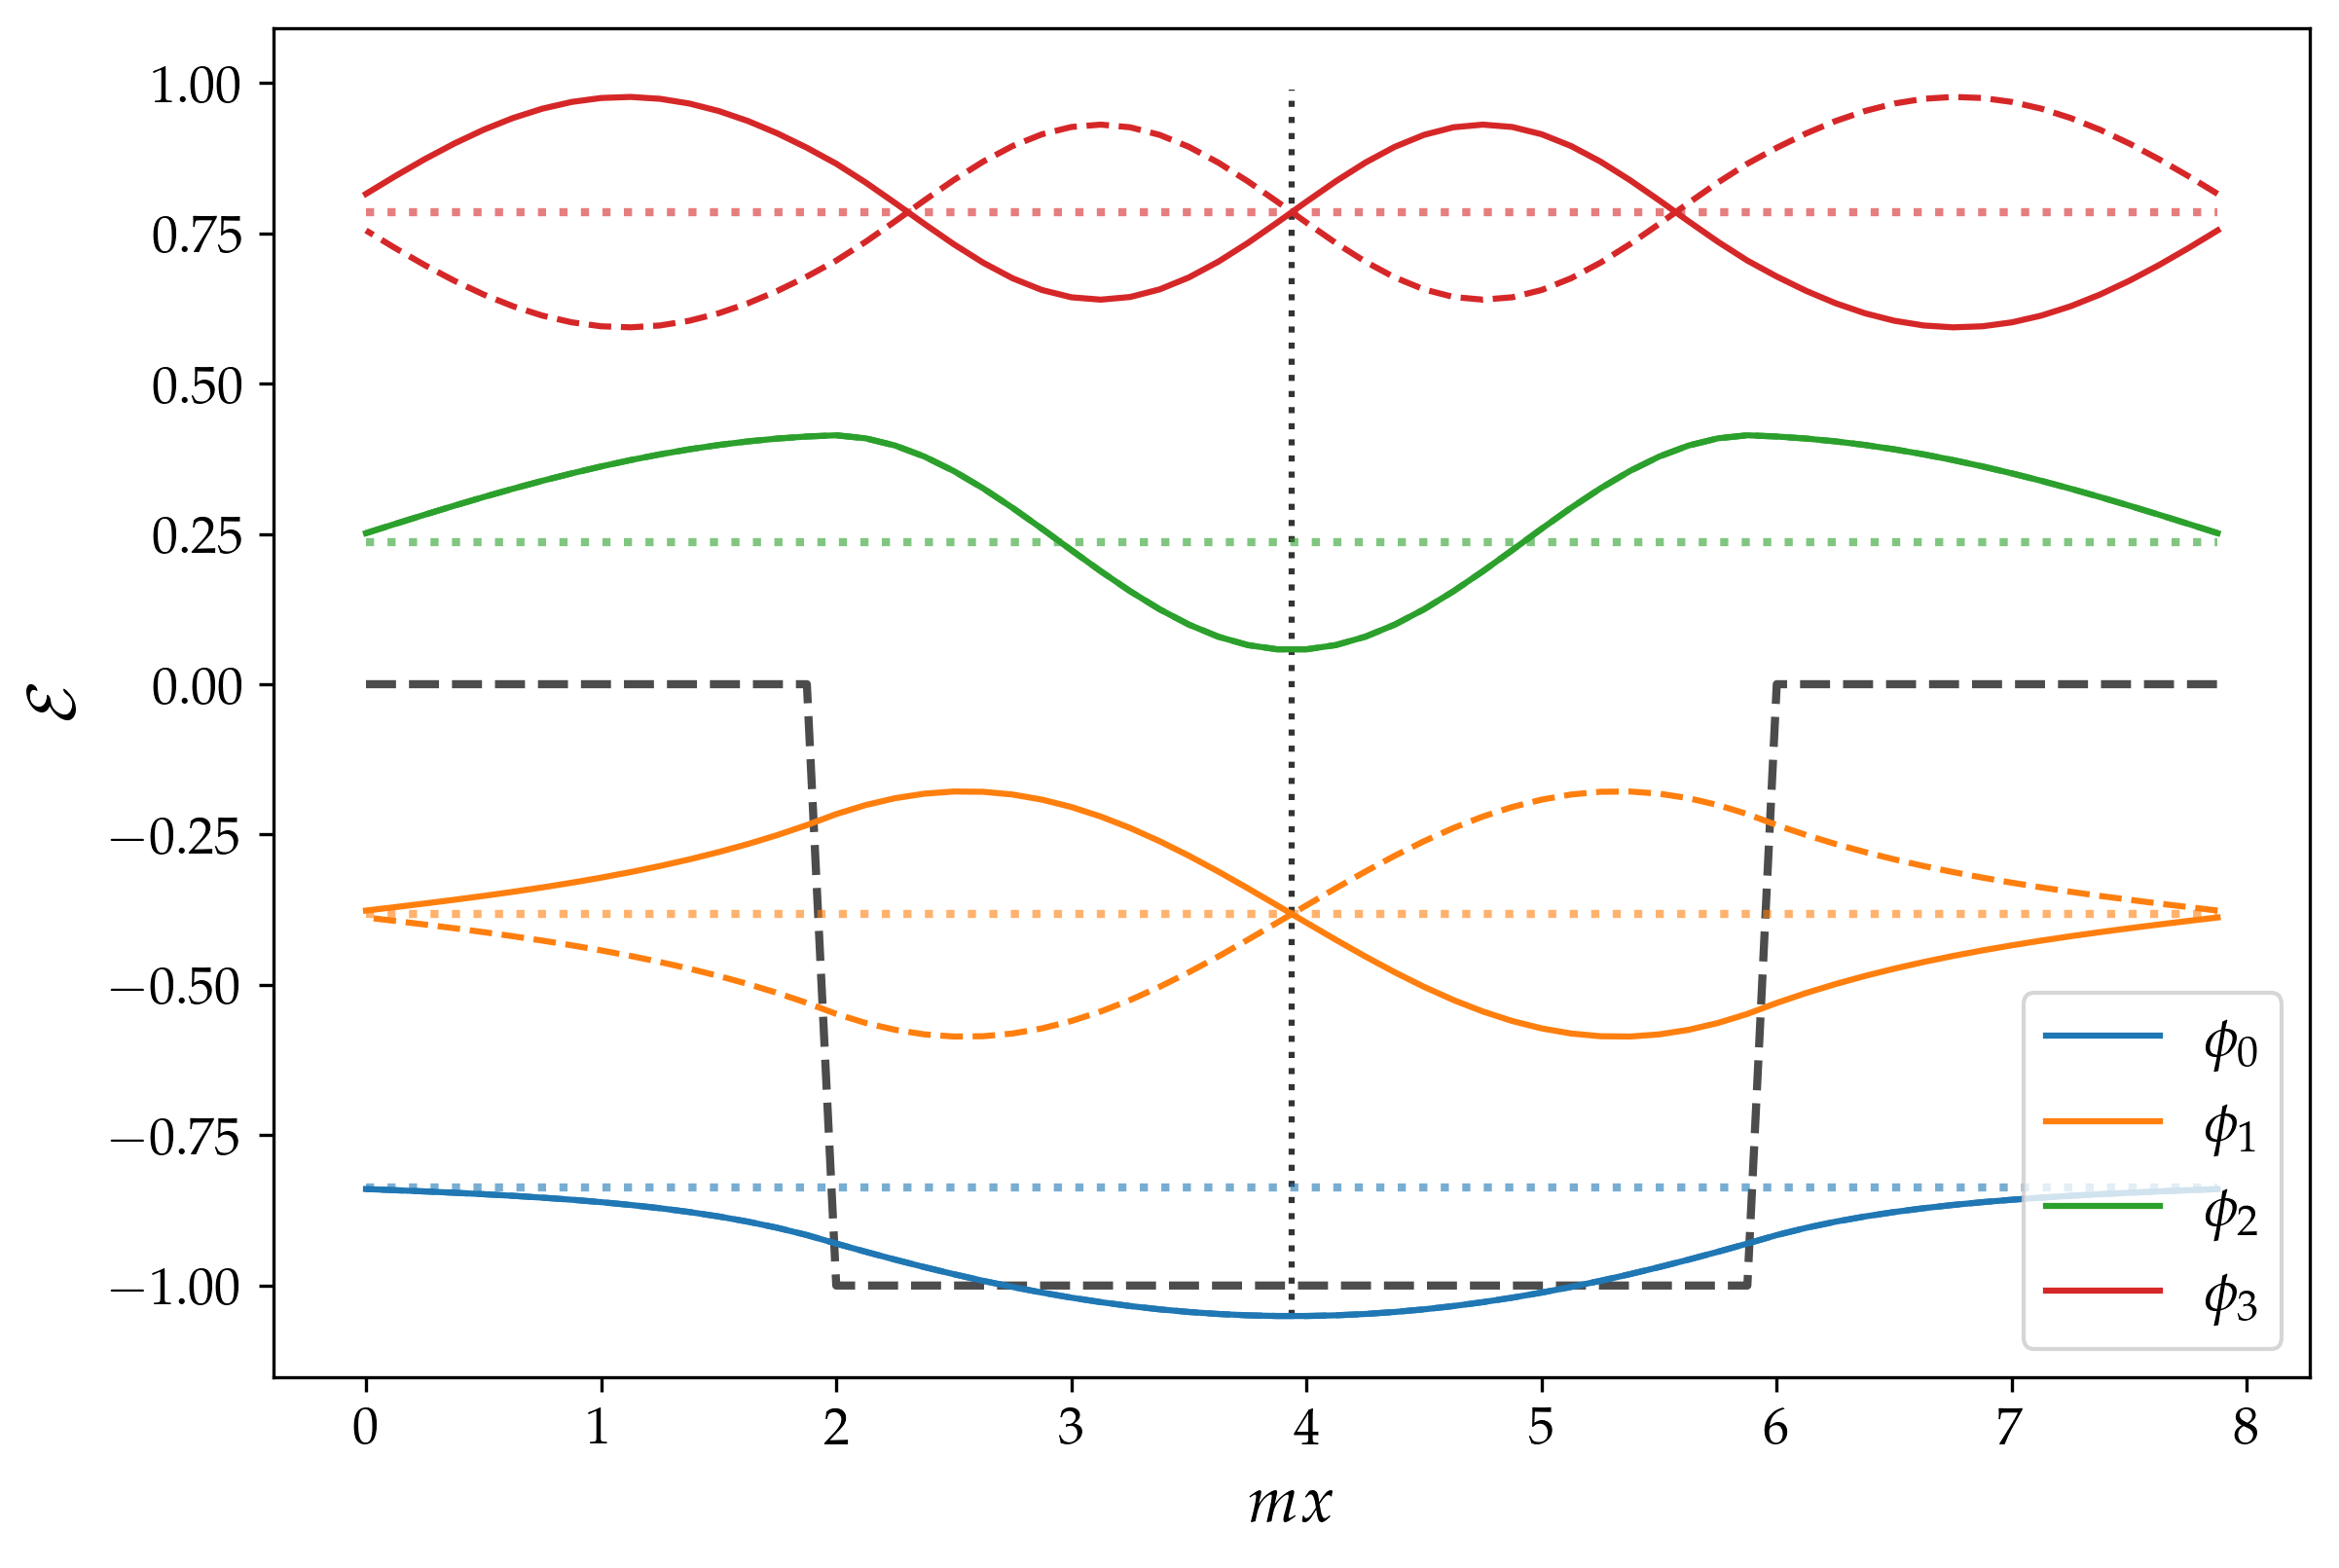

In [36]:
from data_V import N_points, V0_L, mL, StaticV

tot_eig_val = np.loadtxt('txts/V_values.txt')
tot_eig_vect = np.loadtxt('txts/V_vectors.txt')

mL = 8
N = 64

selec = 4
eig_val = np.copy(tot_eig_val)[:selec]
eig_vect = np.copy(tot_eig_vect)[:, :selec].T

print('Eigenvalues =', eig_val)


x_coo = np.arange(0, N_points)
x_mL = np.arange(0, N_points) * (mL / N)
# cols = color_map(np.linspace(0, 1, selec))
cols = [f'C{i}' for i in range(10)]

plt.figure(figsize=(9, 6))
plt.plot(x_mL, StaticV(x_coo), color='black', ls='--', alpha=0.7, lw=2)
for i, eig in enumerate(eig_val):
    plt.hlines(eig, min(x_mL), max(x_mL), color=cols[i], ls=':', alpha=0.6, lw=2)
    plt.plot(x_mL, eig_vect[i] + eig, color=cols[i], zorder=2,
             label=rf'$\phi_{i}$')
    # symmetry
    plt.plot(np.flip(x_mL), eig_vect[i] + eig, color=cols[i], ls='--', zorder=2)

plt.vlines(x_mL[-1]/2, np.min(eig_vect)+eig_val[0], np.max(eig_vect)+eig_val[-1],
           color='black', ls=':', zorder=0, alpha=0.8)

plt.xlabel(r'$mx$')
plt.ylabel(r'$\mathcal{E}$')
plt.legend(loc='lower right')

plt.savefig('plots/finite_well.png')
plt.show()

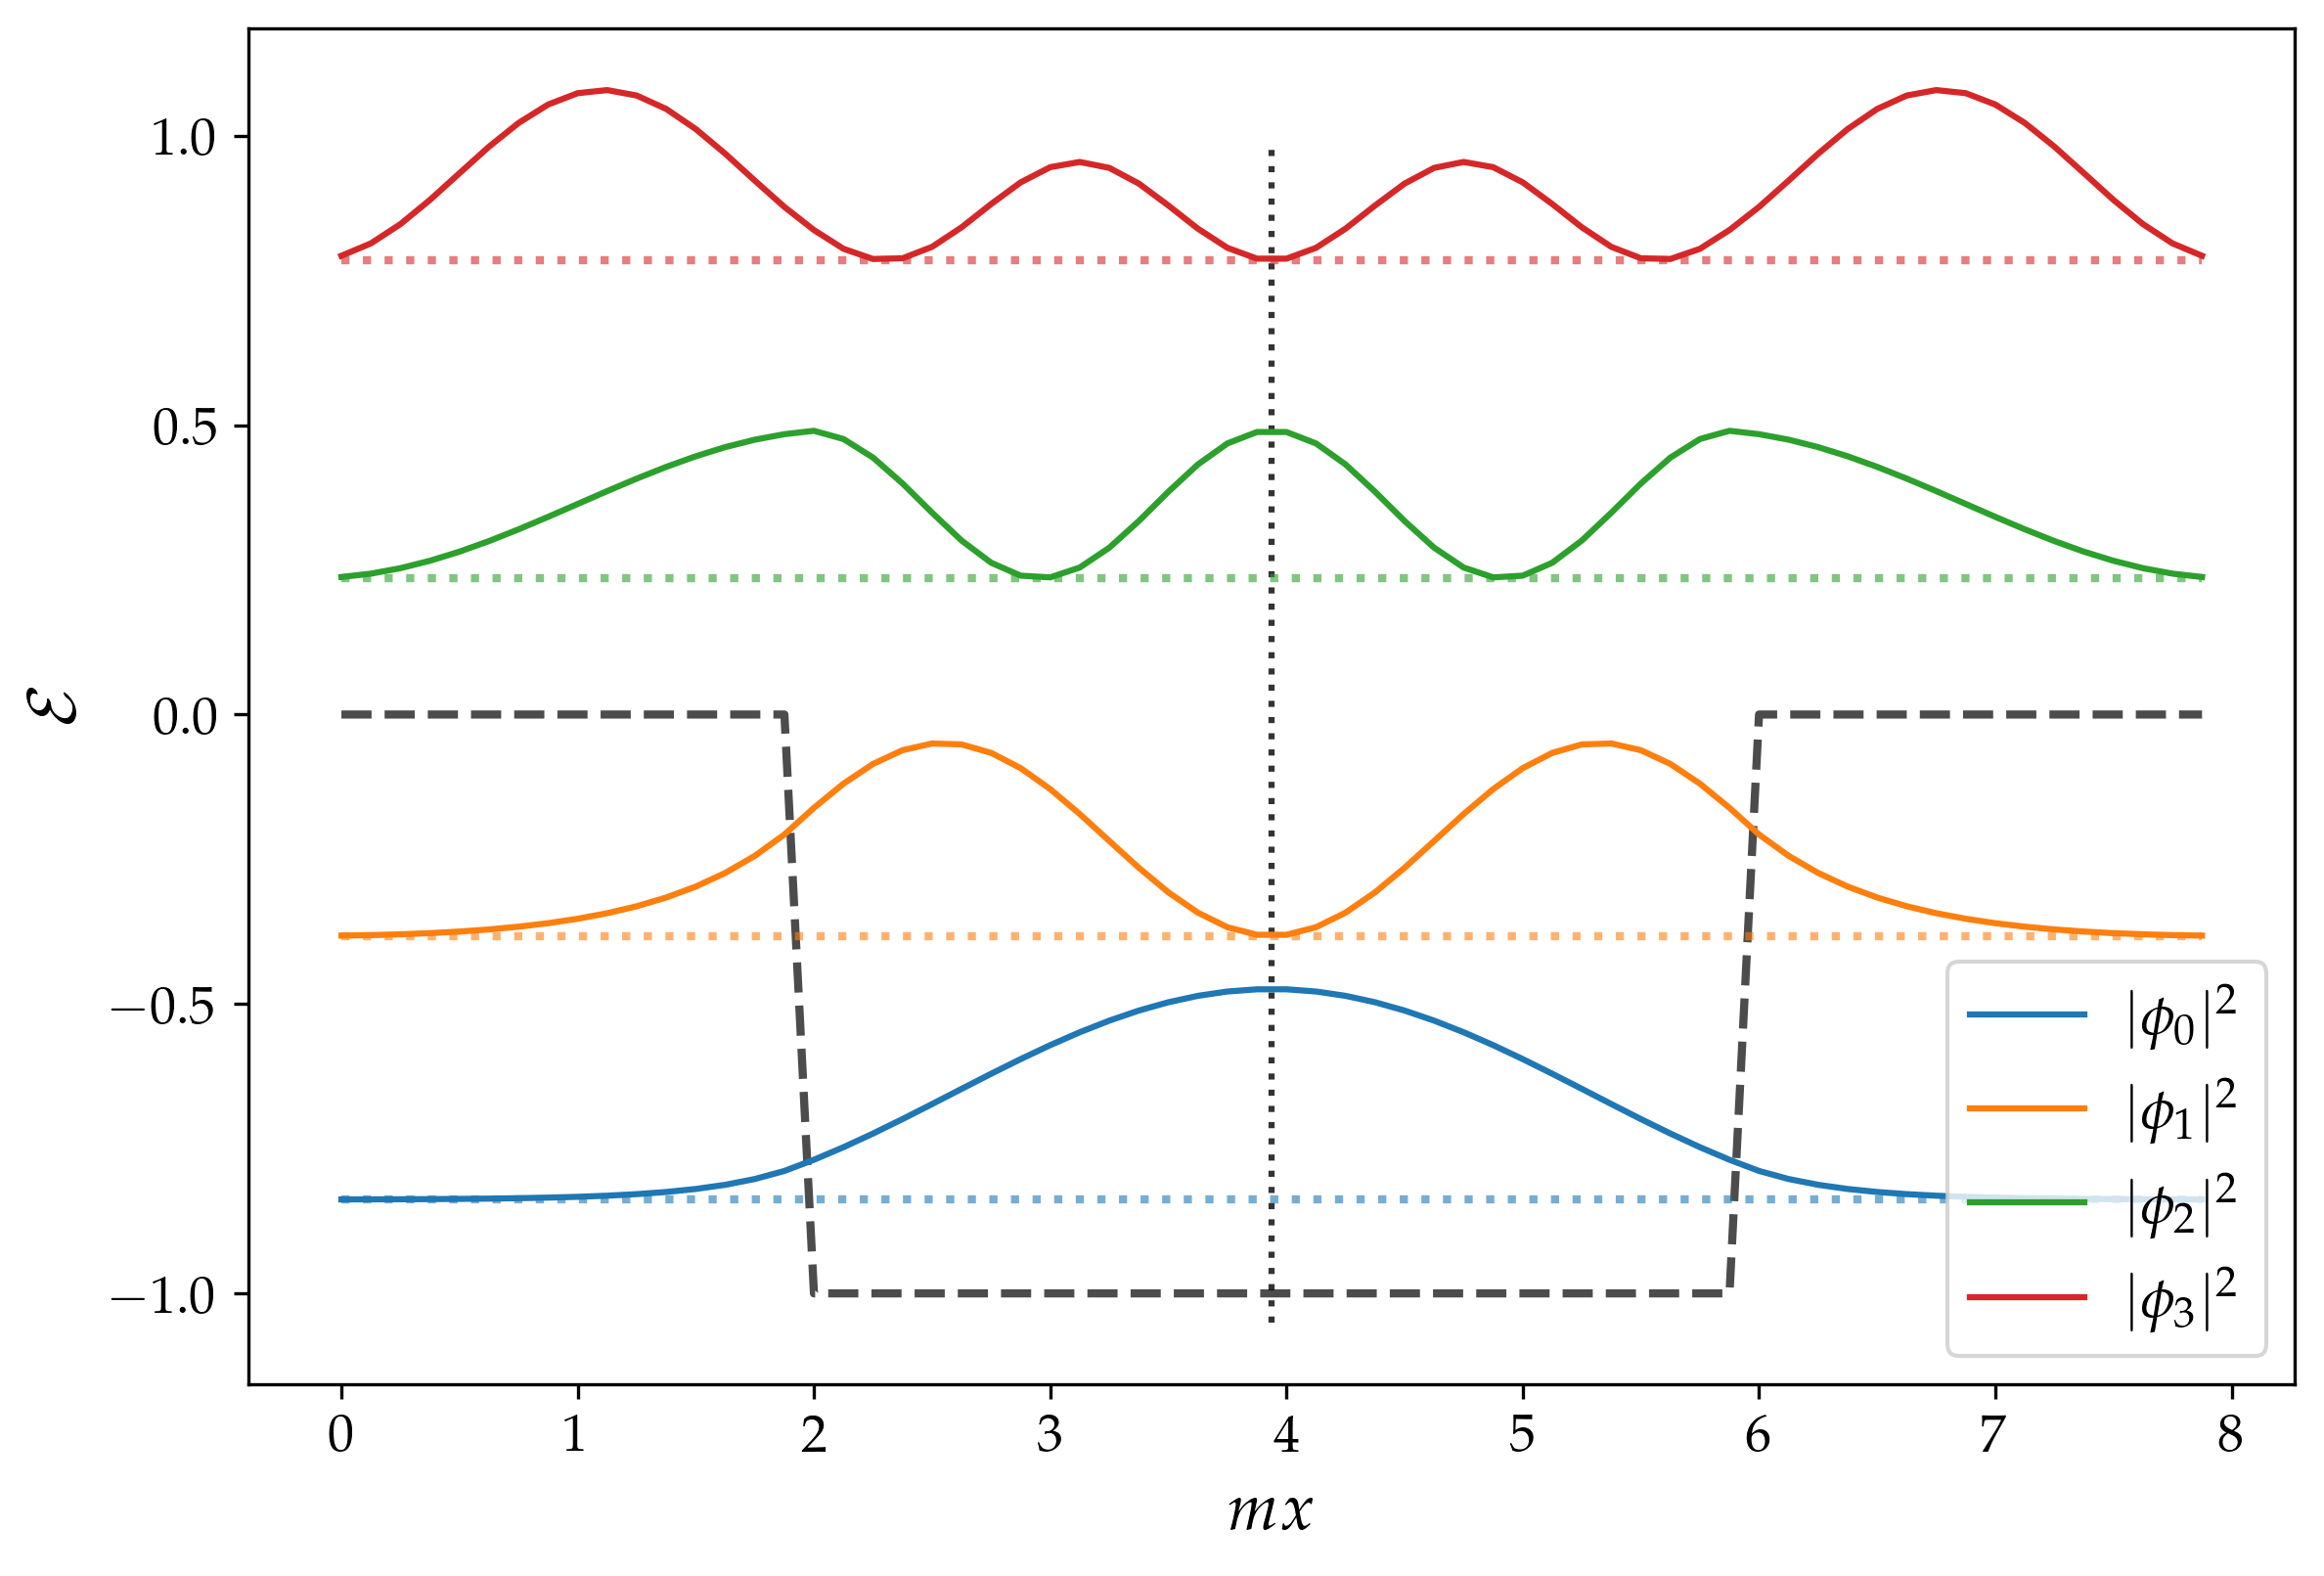

In [37]:

plt.figure(figsize=(9, 6))
plt.plot(x_mL, StaticV(x_coo), color='black', ls='--', alpha=0.7, 
         lw=2)
for i, eig in enumerate(eig_val):
    plt.hlines(eig, min(x_mL), max(x_mL), color=cols[i], ls=':', alpha=0.6, lw=2)
    
    plt.plot(x_mL, mL * (eig_vect[i])**2 + eig, color=cols[i], zorder=2,
             label=rf'$|\phi_{i}|^2$')

plt.vlines(x_mL[-1]/2, np.min(eig_vect) +eig_val[0], np.max(eig_vect) +eig_val[-1],
           color='black', ls=':', zorder=0, alpha=0.8)

plt.xlabel(r'$mx$')
plt.ylabel(r'$\mathcal{E}$')
plt.legend(loc='lower right')

plt.savefig('plots/finite_well_mod2.png')
plt.show()

## **Degenerazioni**

Eigenvalues = [0.57728706 0.59382151 1.26514315 1.77476222]


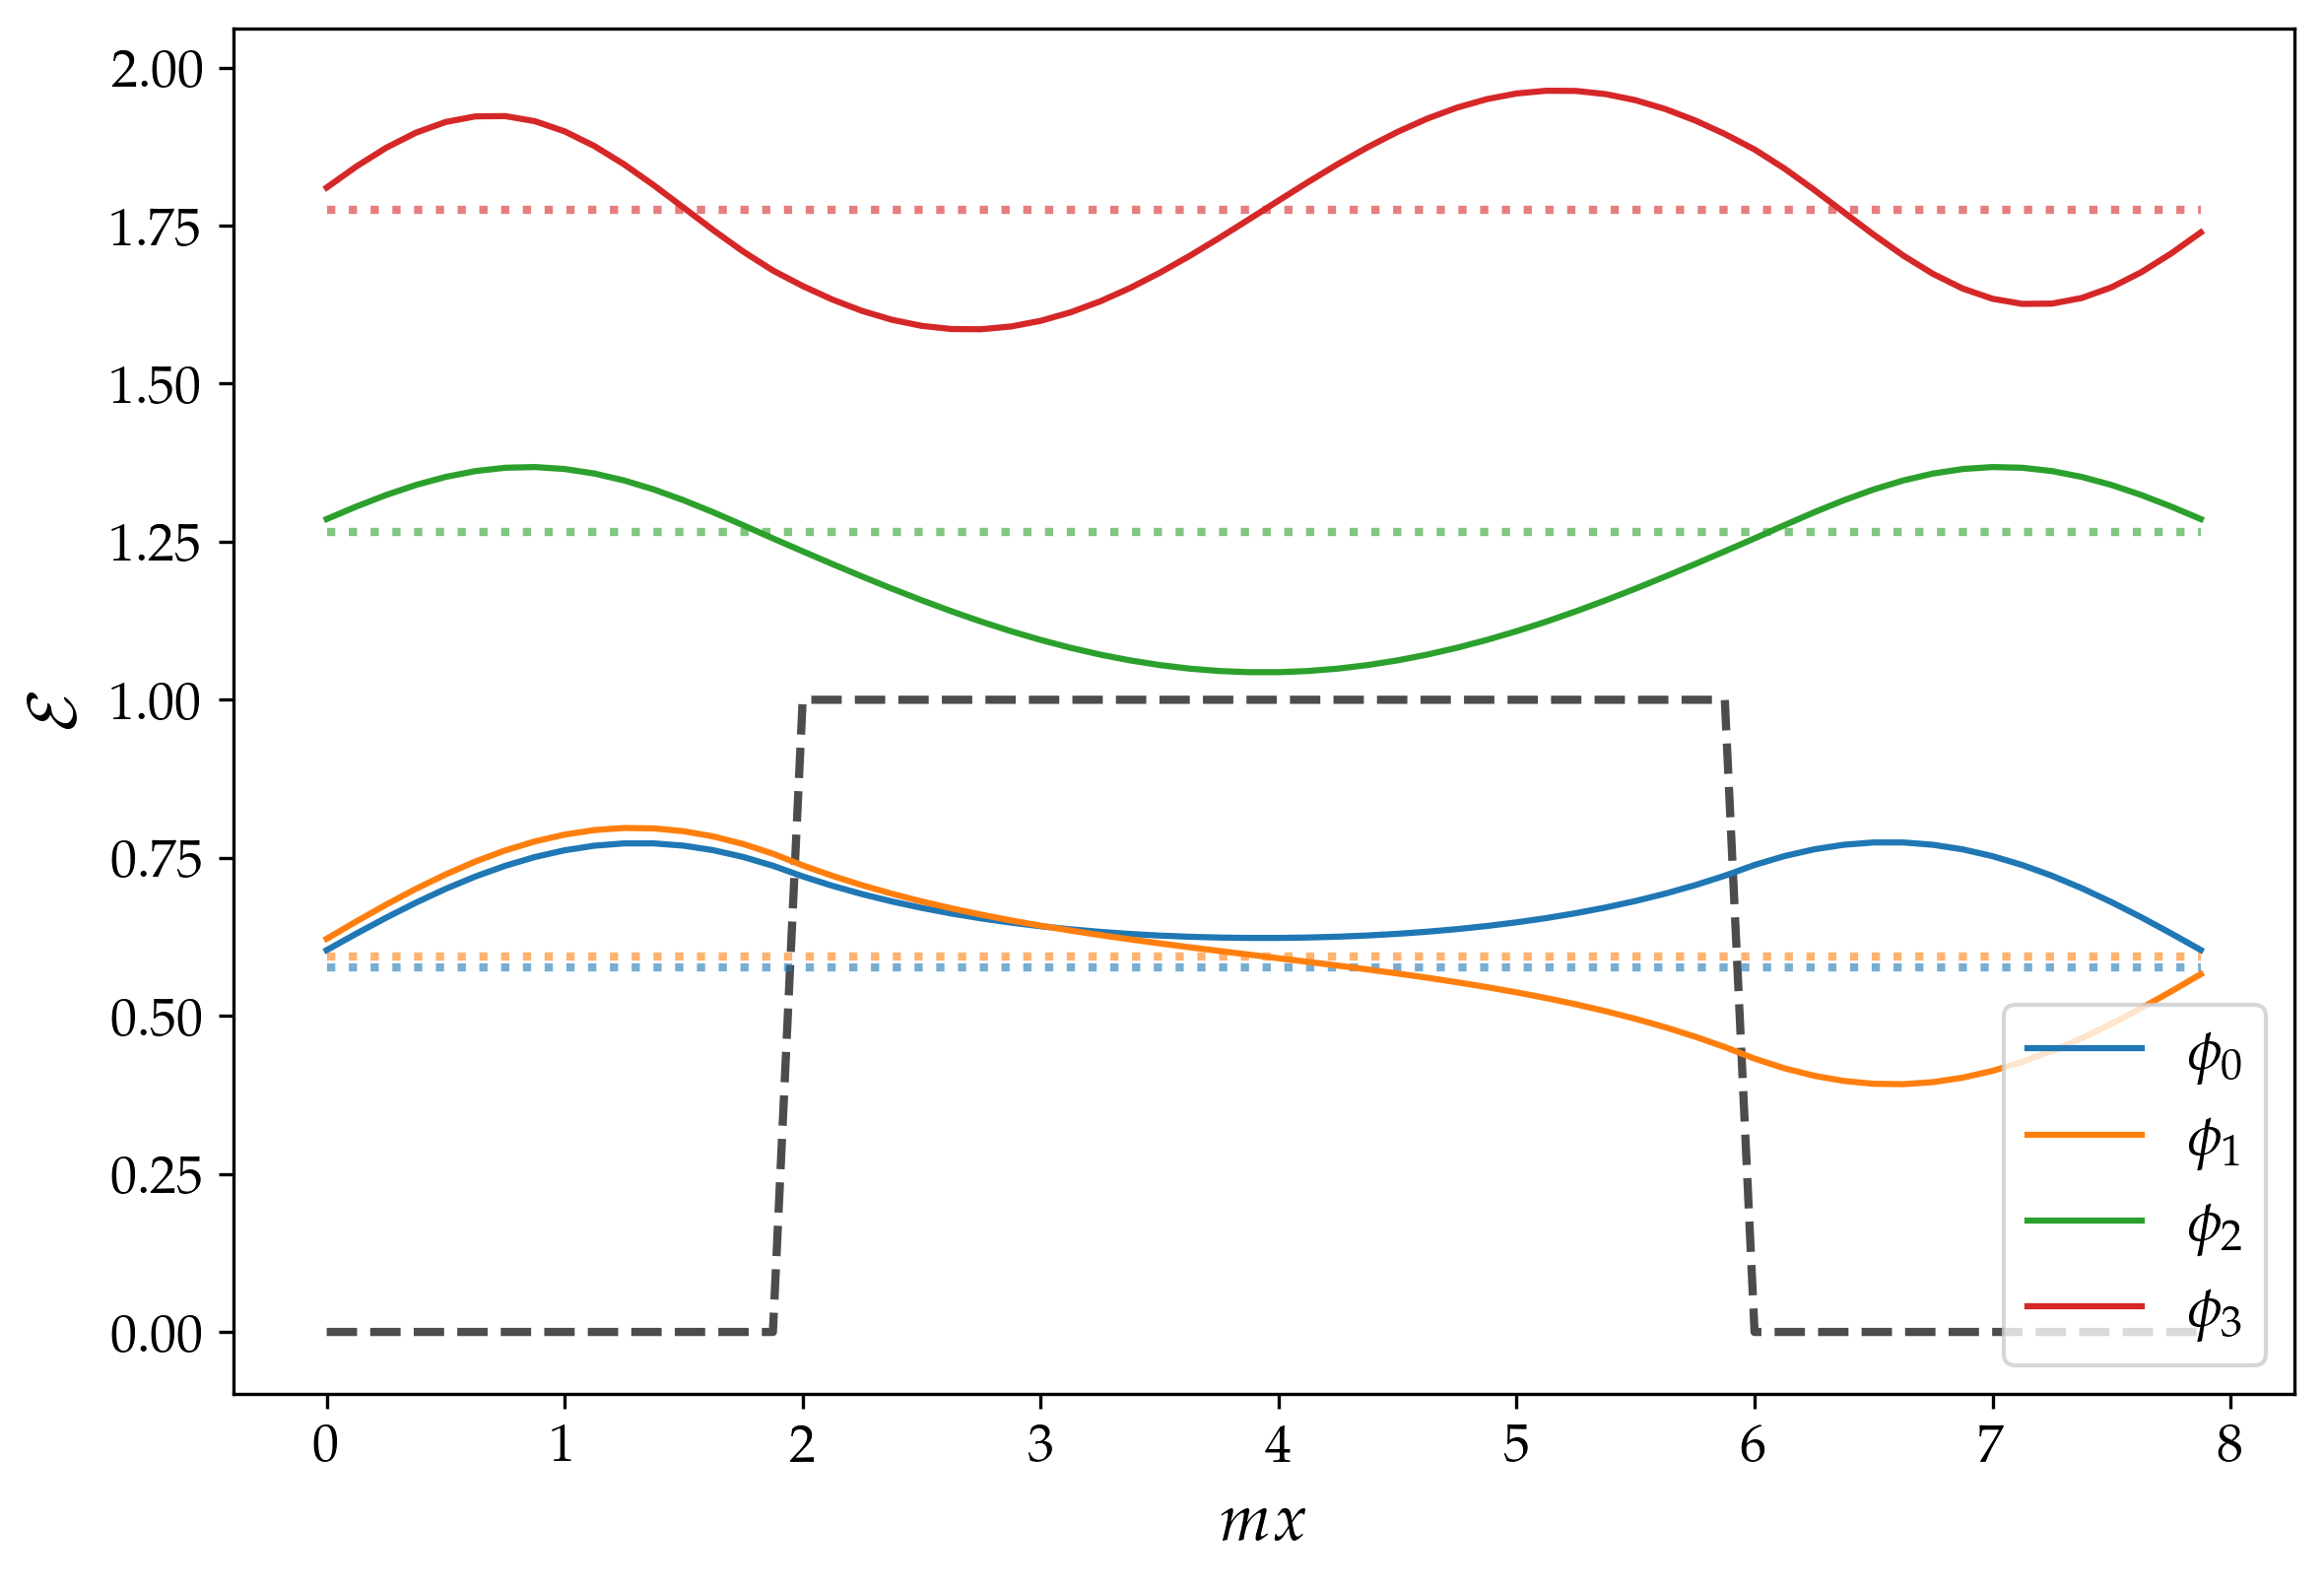

In [38]:
from data_mV import N_points, V0_L, mL, StaticV
tot_eig_val = np.loadtxt('txts/mV_values.txt')
tot_eig_vect = np.loadtxt('txts/mV_vectors.txt')

selec = 4
eig_val = np.copy(tot_eig_val)[:selec]
eig_vect = np.copy(tot_eig_vect)[:, :selec].T

print('Eigenvalues =', eig_val)

plt.figure(figsize=(9, 6))
plt.plot(x_mL, StaticV(x_coo), color='black', ls='--', alpha=0.7, 
         lw=2)
for i, eig in enumerate(eig_val):
    plt.hlines(eig, min(x_mL), max(x_mL), color=cols[i], ls=':', alpha=0.6, lw=2)
    plt.plot(x_mL,  eig_vect[i] + eig, color=cols[i], zorder=2,
             label=rf'$\phi_{i}$')
    # symmetry
    # plt.plot(np.flip(x_mL),  eig_vect[i] + eig, color=cols[i], ls='--', zorder=2)

# plt.vlines(x_mL[-1]/2, 0, np.max(eig_vect) +eig_val[-1],
#            color='black', ls=':', zorder=0, alpha=0.8)

plt.xlabel(r'$mx$')
plt.ylabel(r'$\mathcal{E}$')
plt.legend(loc='lower right')

plt.savefig('plots/finite_wall.png')
plt.show()

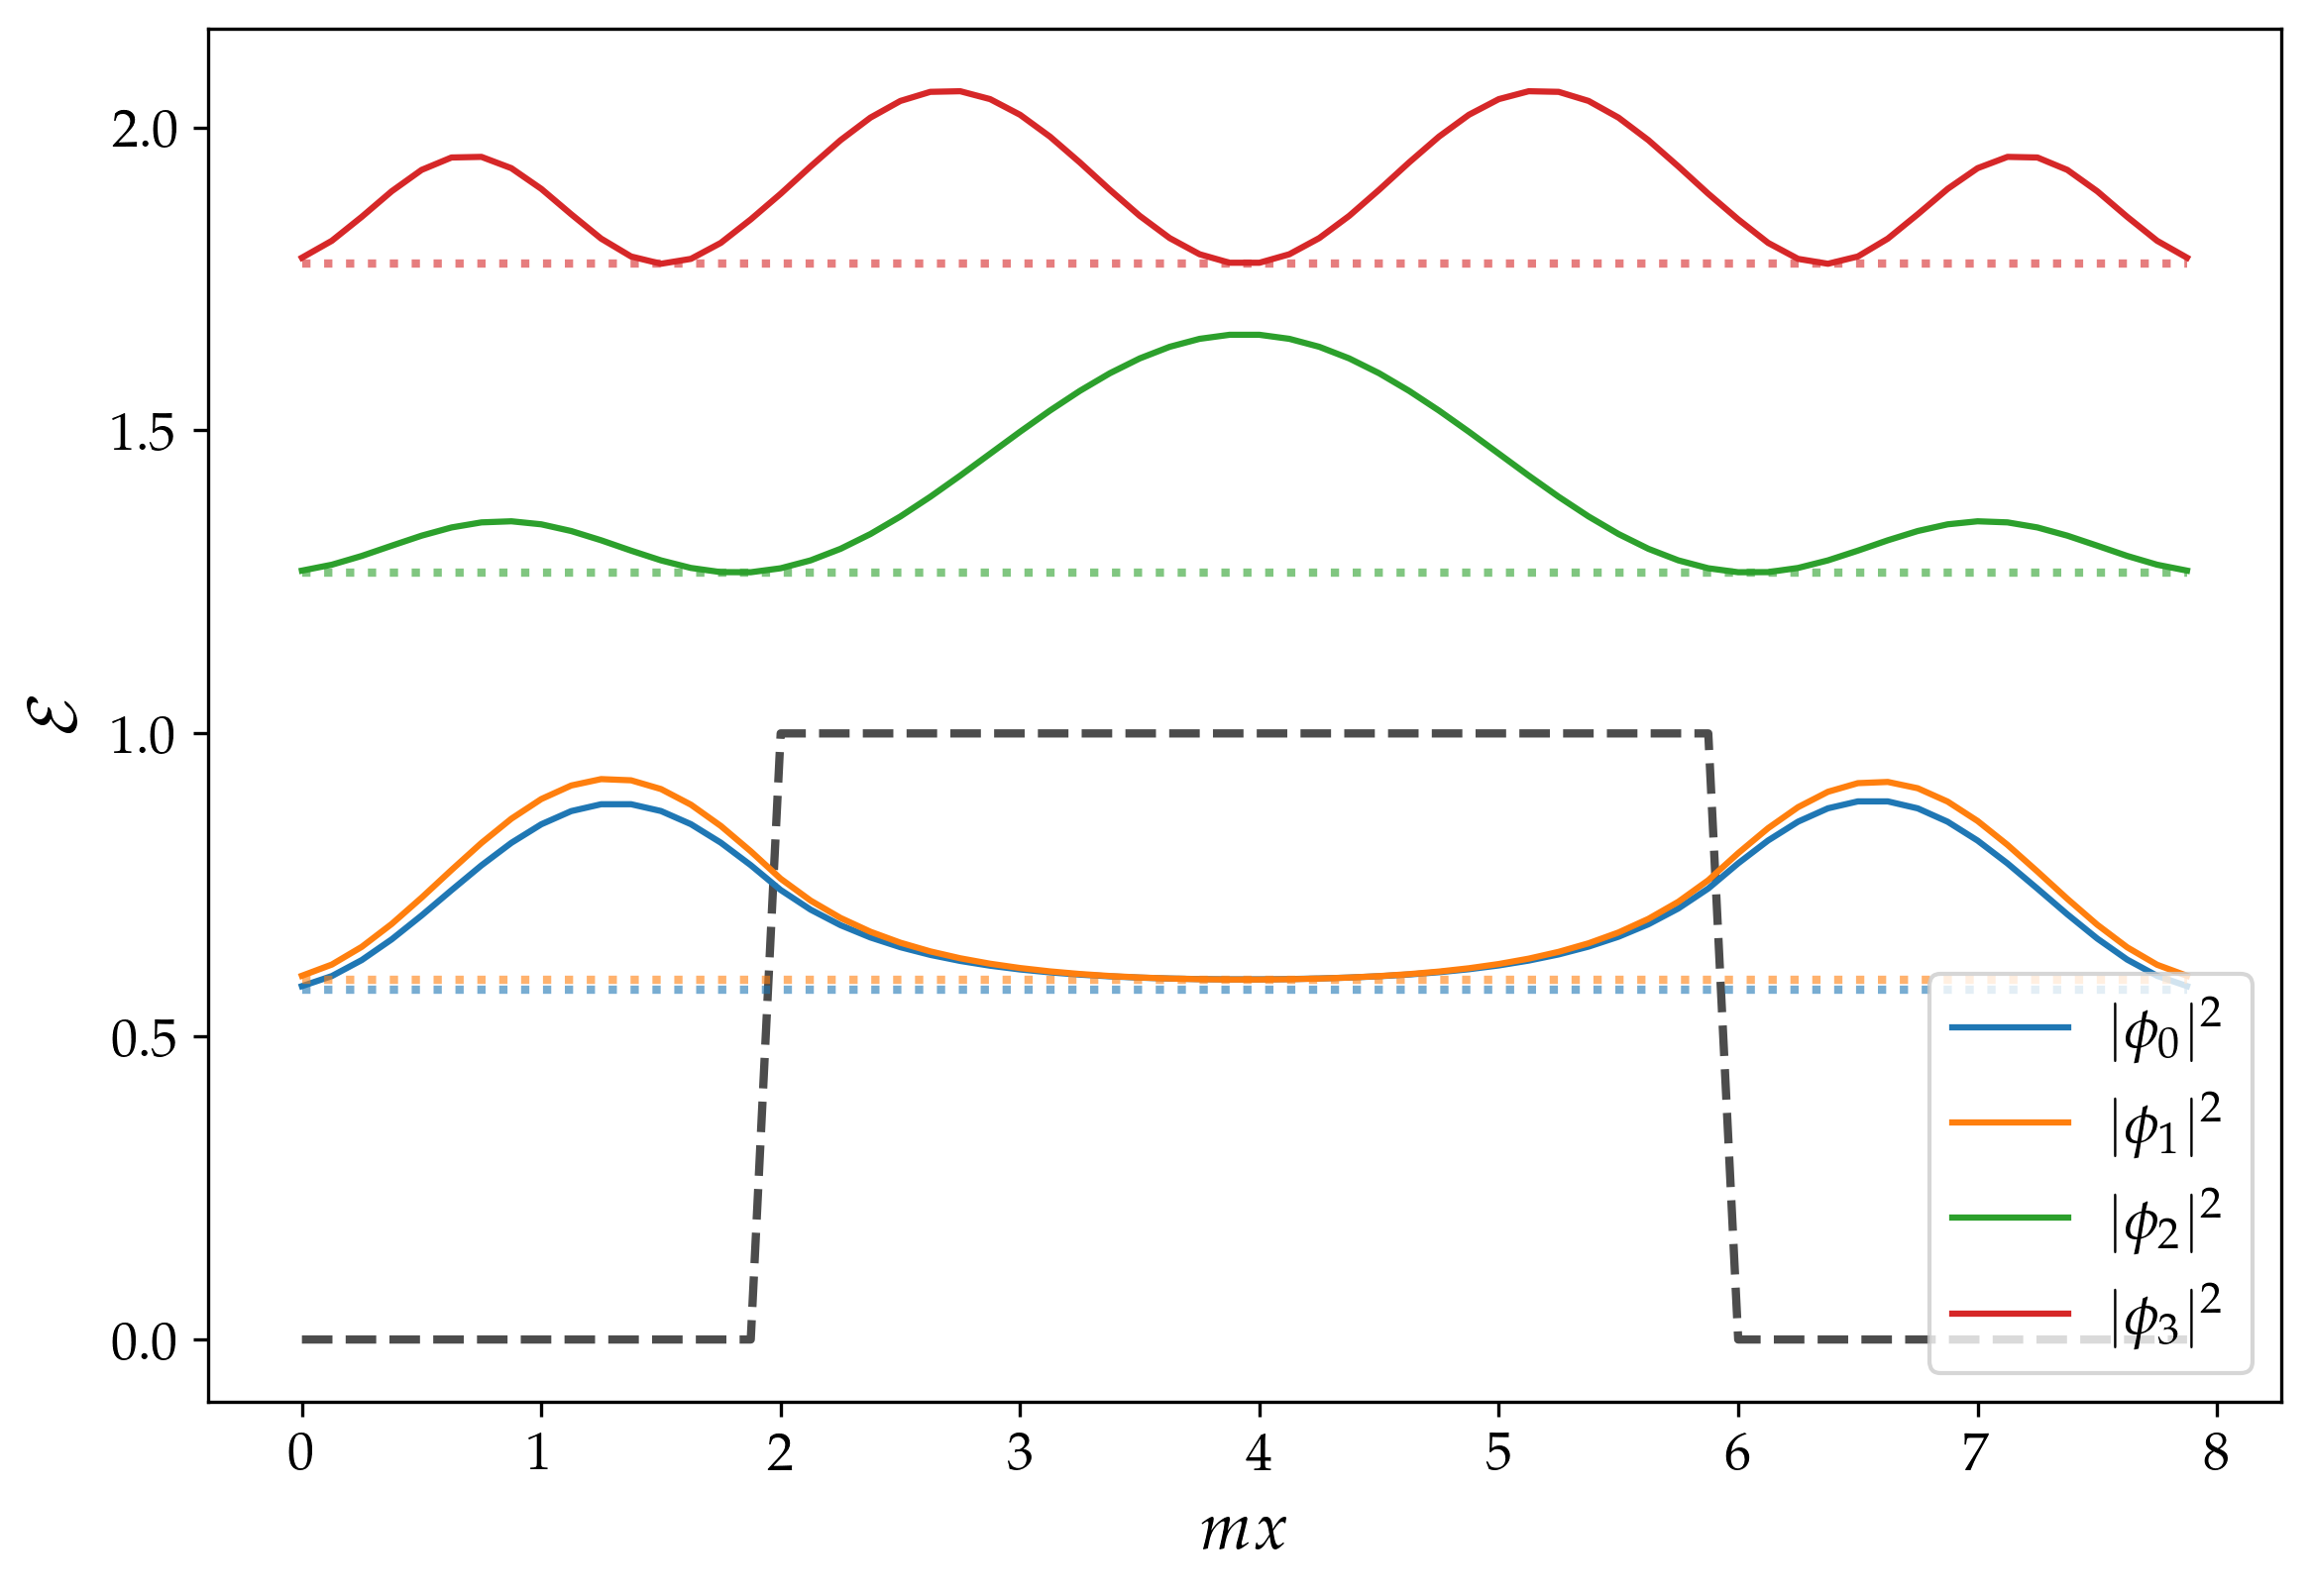

In [39]:

eig_vect = eig_vect**2 * mL

plt.figure(figsize=(9, 6))
plt.plot(x_mL, StaticV(x_coo), color='black', ls='--', alpha=0.7, 
         lw=2)
for i, eig in enumerate(eig_val):
    plt.hlines(eig, min(x_mL), max(x_mL), color=cols[i], ls=':', alpha=0.6, lw=2)
    plt.plot(x_mL, eig_vect[i] + eig, color=cols[i], zorder=2,
             label=rf'$|\phi_{i}|^2$')

plt.xlabel(r'$mx$')
plt.ylabel(r'$\mathcal{E}$')
plt.legend(loc='lower right')

plt.savefig('plots/finite_wall_mod2.png')
plt.show()

## **Ground states**

Eigenvalues = [-0.83767458 -3.78485506 -7.7650436 ]


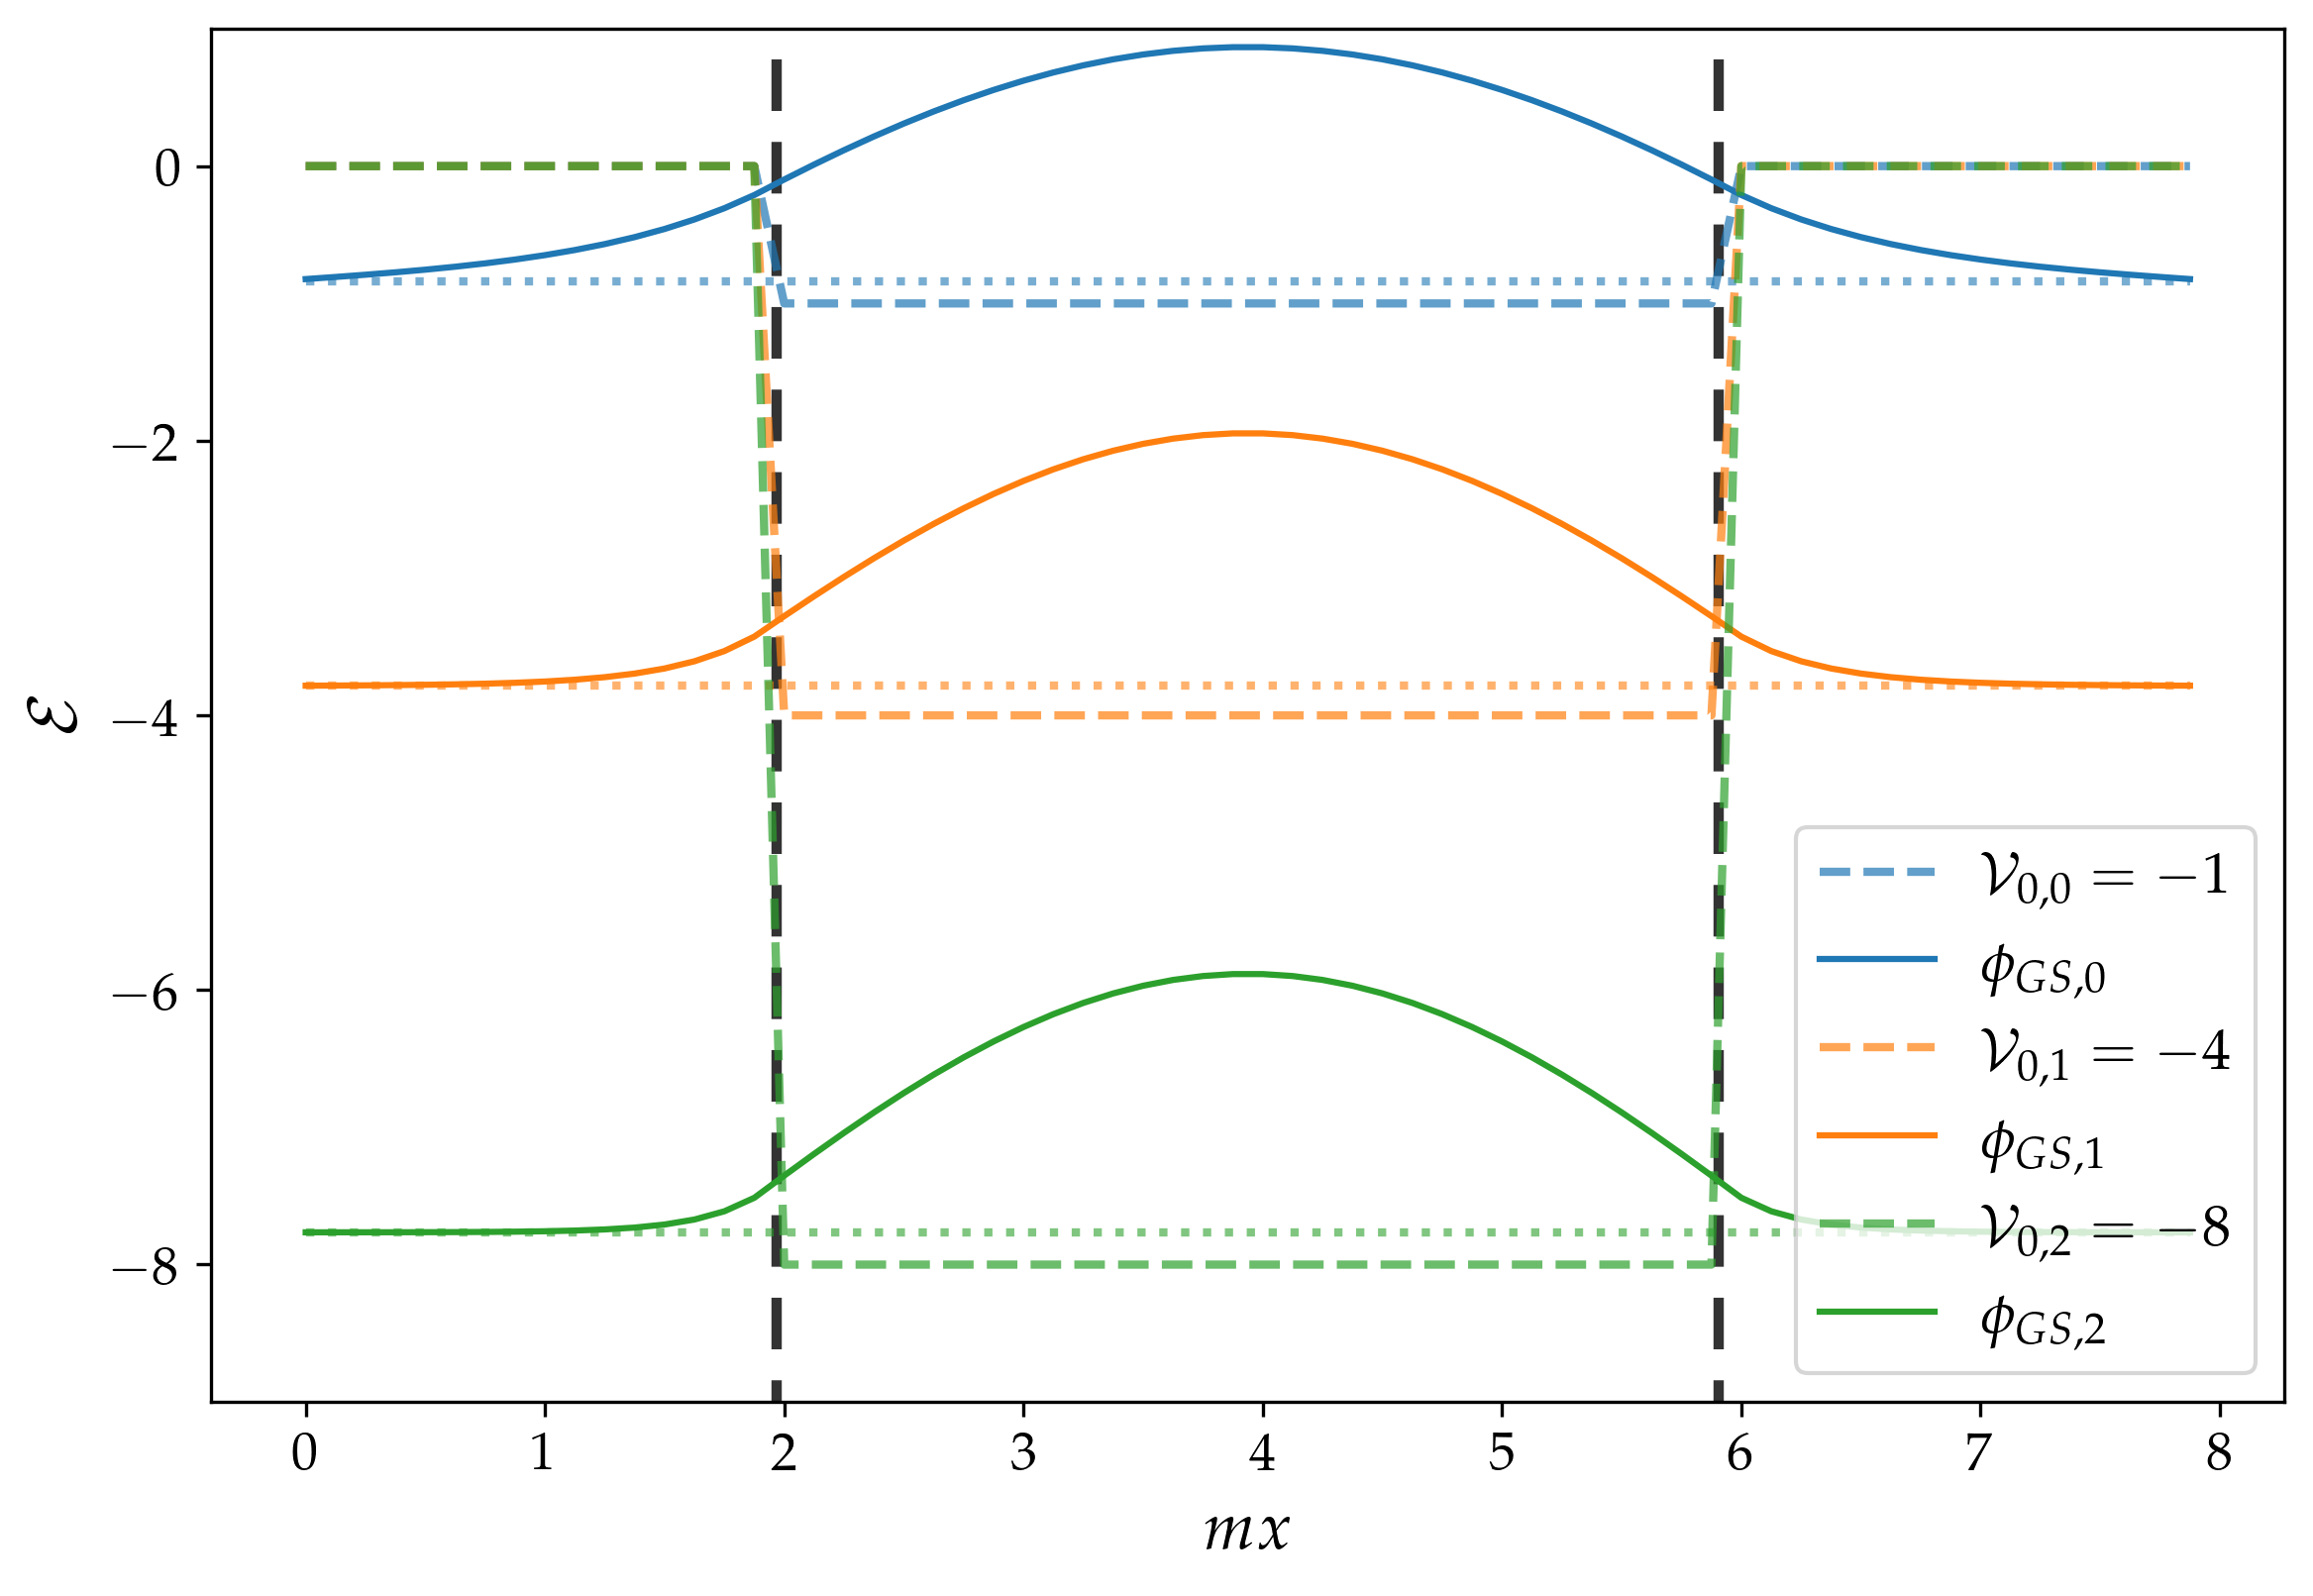

In [40]:

from data_comp import N_points, v_ls, mL
eig_val = np.loadtxt('txts/ground_val.txt')
eig_vect = np.loadtxt('txts/ground_vect.txt')

print('Eigenvalues =', eig_val)

plt.figure(figsize=(9, 6))
for i, eig in enumerate(eig_val):
    def StaticV(x):
        x = np.asarray(x)
        return np.where((x < N_points/4) | (x >= 3/4 * N_points), 0, -v_ls[i])

    plt.plot(x_mL, StaticV(x_coo), color=cols[i], ls='--', alpha=0.7, lw=2,
             label=rf'$\mathcal{{V}}_{{0,{i}}} = -{v_ls[i]}$')
    plt.hlines(eig, min(x_mL), max(x_mL), color=cols[i], ls=':', alpha=0.6, lw=2)
    plt.plot(x_mL, abs(mL* eig_vect[i]) + eig, color=cols[i], zorder=2,
             label=rf'$\phi_{{GS,{i}}}$')

bordo = 20
for mul in [1/4, 3/4]:
    plt.vlines(x_mL[-1]*mul, -v_ls[-1]-bordo, bordo,
            color='black', ls=(0, (5, 3)), zorder=0, alpha=0.8, lw=2.5)
plt.ylim(-np.max(v_ls)-1, 1)
plt.xlabel(r'$mx$')
plt.ylabel(r'$\mathcal{E}$')
plt.legend(loc='lower right')

plt.savefig('plots/diff_well.png')
plt.show()

## **Scaling of the eigenvalues**

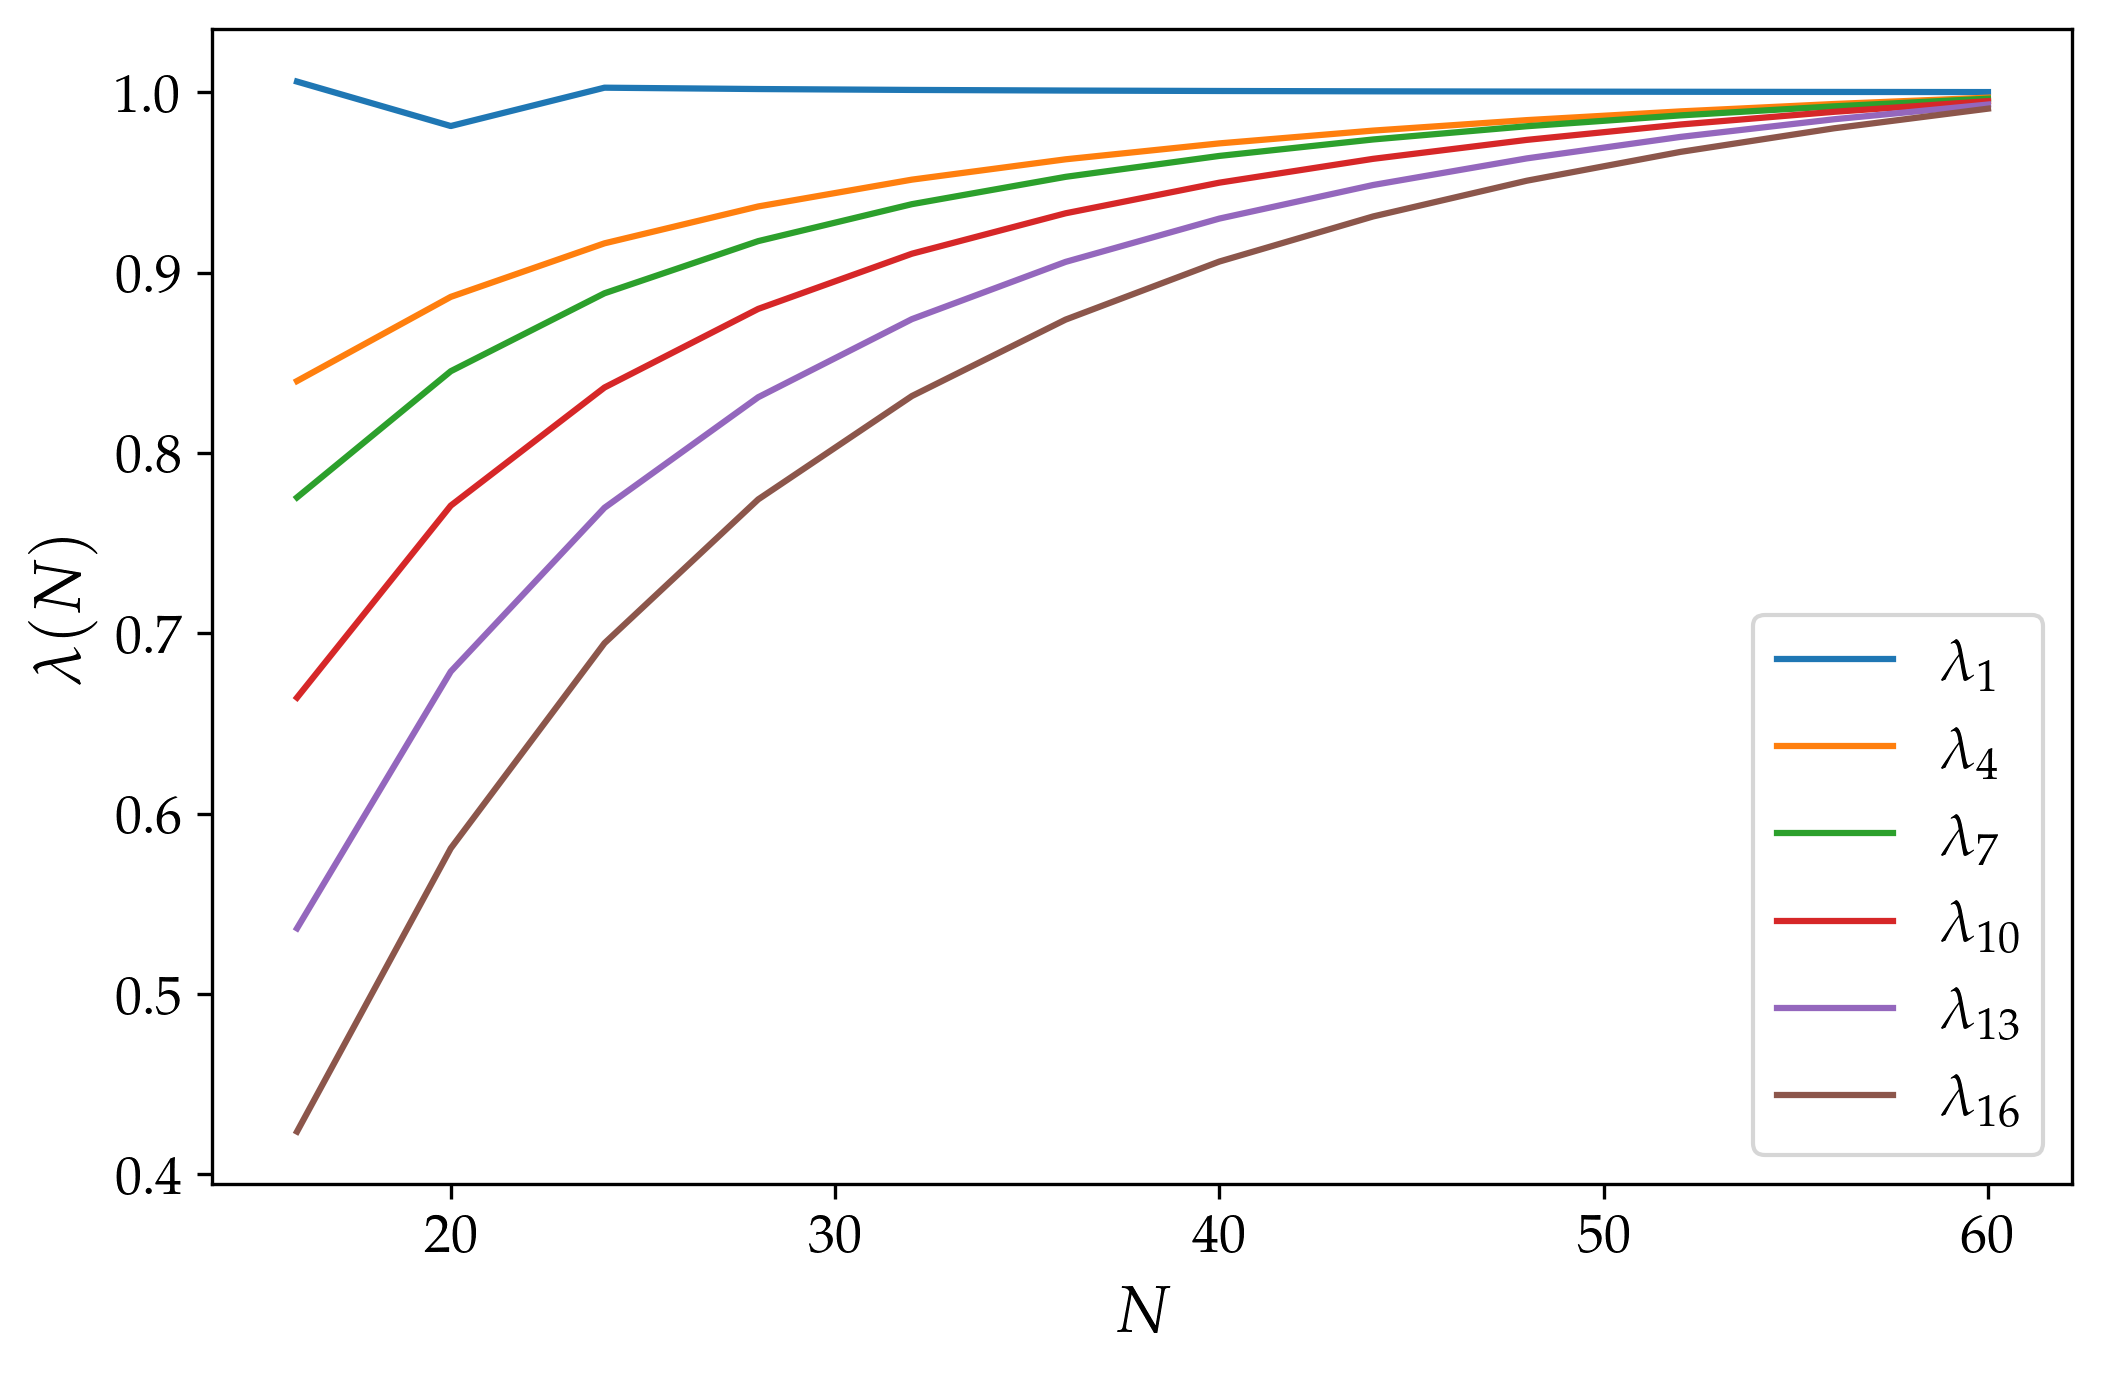

In [ ]:

from func_N import N_ls, orders
eig_val = np.loadtxt('txts/scal_N_val.txt')
# print('Eigenvalues =\n', eig_val.T)

eig_i = eig_val[:-1, 0] / eig_val[-1, 0]

plt.figure(figsize=(8,5))
for i in range(len(orders)):
    eig_i = eig_val[:-1, i] / eig_val[-1, i]
    plt.plot(N_ls[:-1], eig_i, label=rf'$\lambda_{{{orders[i]+1}}}$')


plt.xlabel(r'$N$')
plt.ylabel(r'$\lambda (N)$')
plt.legend(loc='lower right')

plt.savefig('plots/rate_N.png')
plt.show()


## **Different $V_0$ models**


-----------------------------------
	Finite well
-----------------------------------
Eigenvalues = [-0.84468613 -0.40611896  0.20371331  0.77382485]

-----------------------------------
	Double well
-----------------------------------
Eigenvalues = [-0.86839085 -0.65178488  0.91351048  2.19164673]

-----------------------------------
	Triangular well
-----------------------------------
Eigenvalues = [2.97710486 5.42871732 7.4308995  9.19669701]

-----------------------------------
	Alpha well
-----------------------------------
Eigenvalues = [-0.28858273  0.22054353  0.60922982  1.15316484]


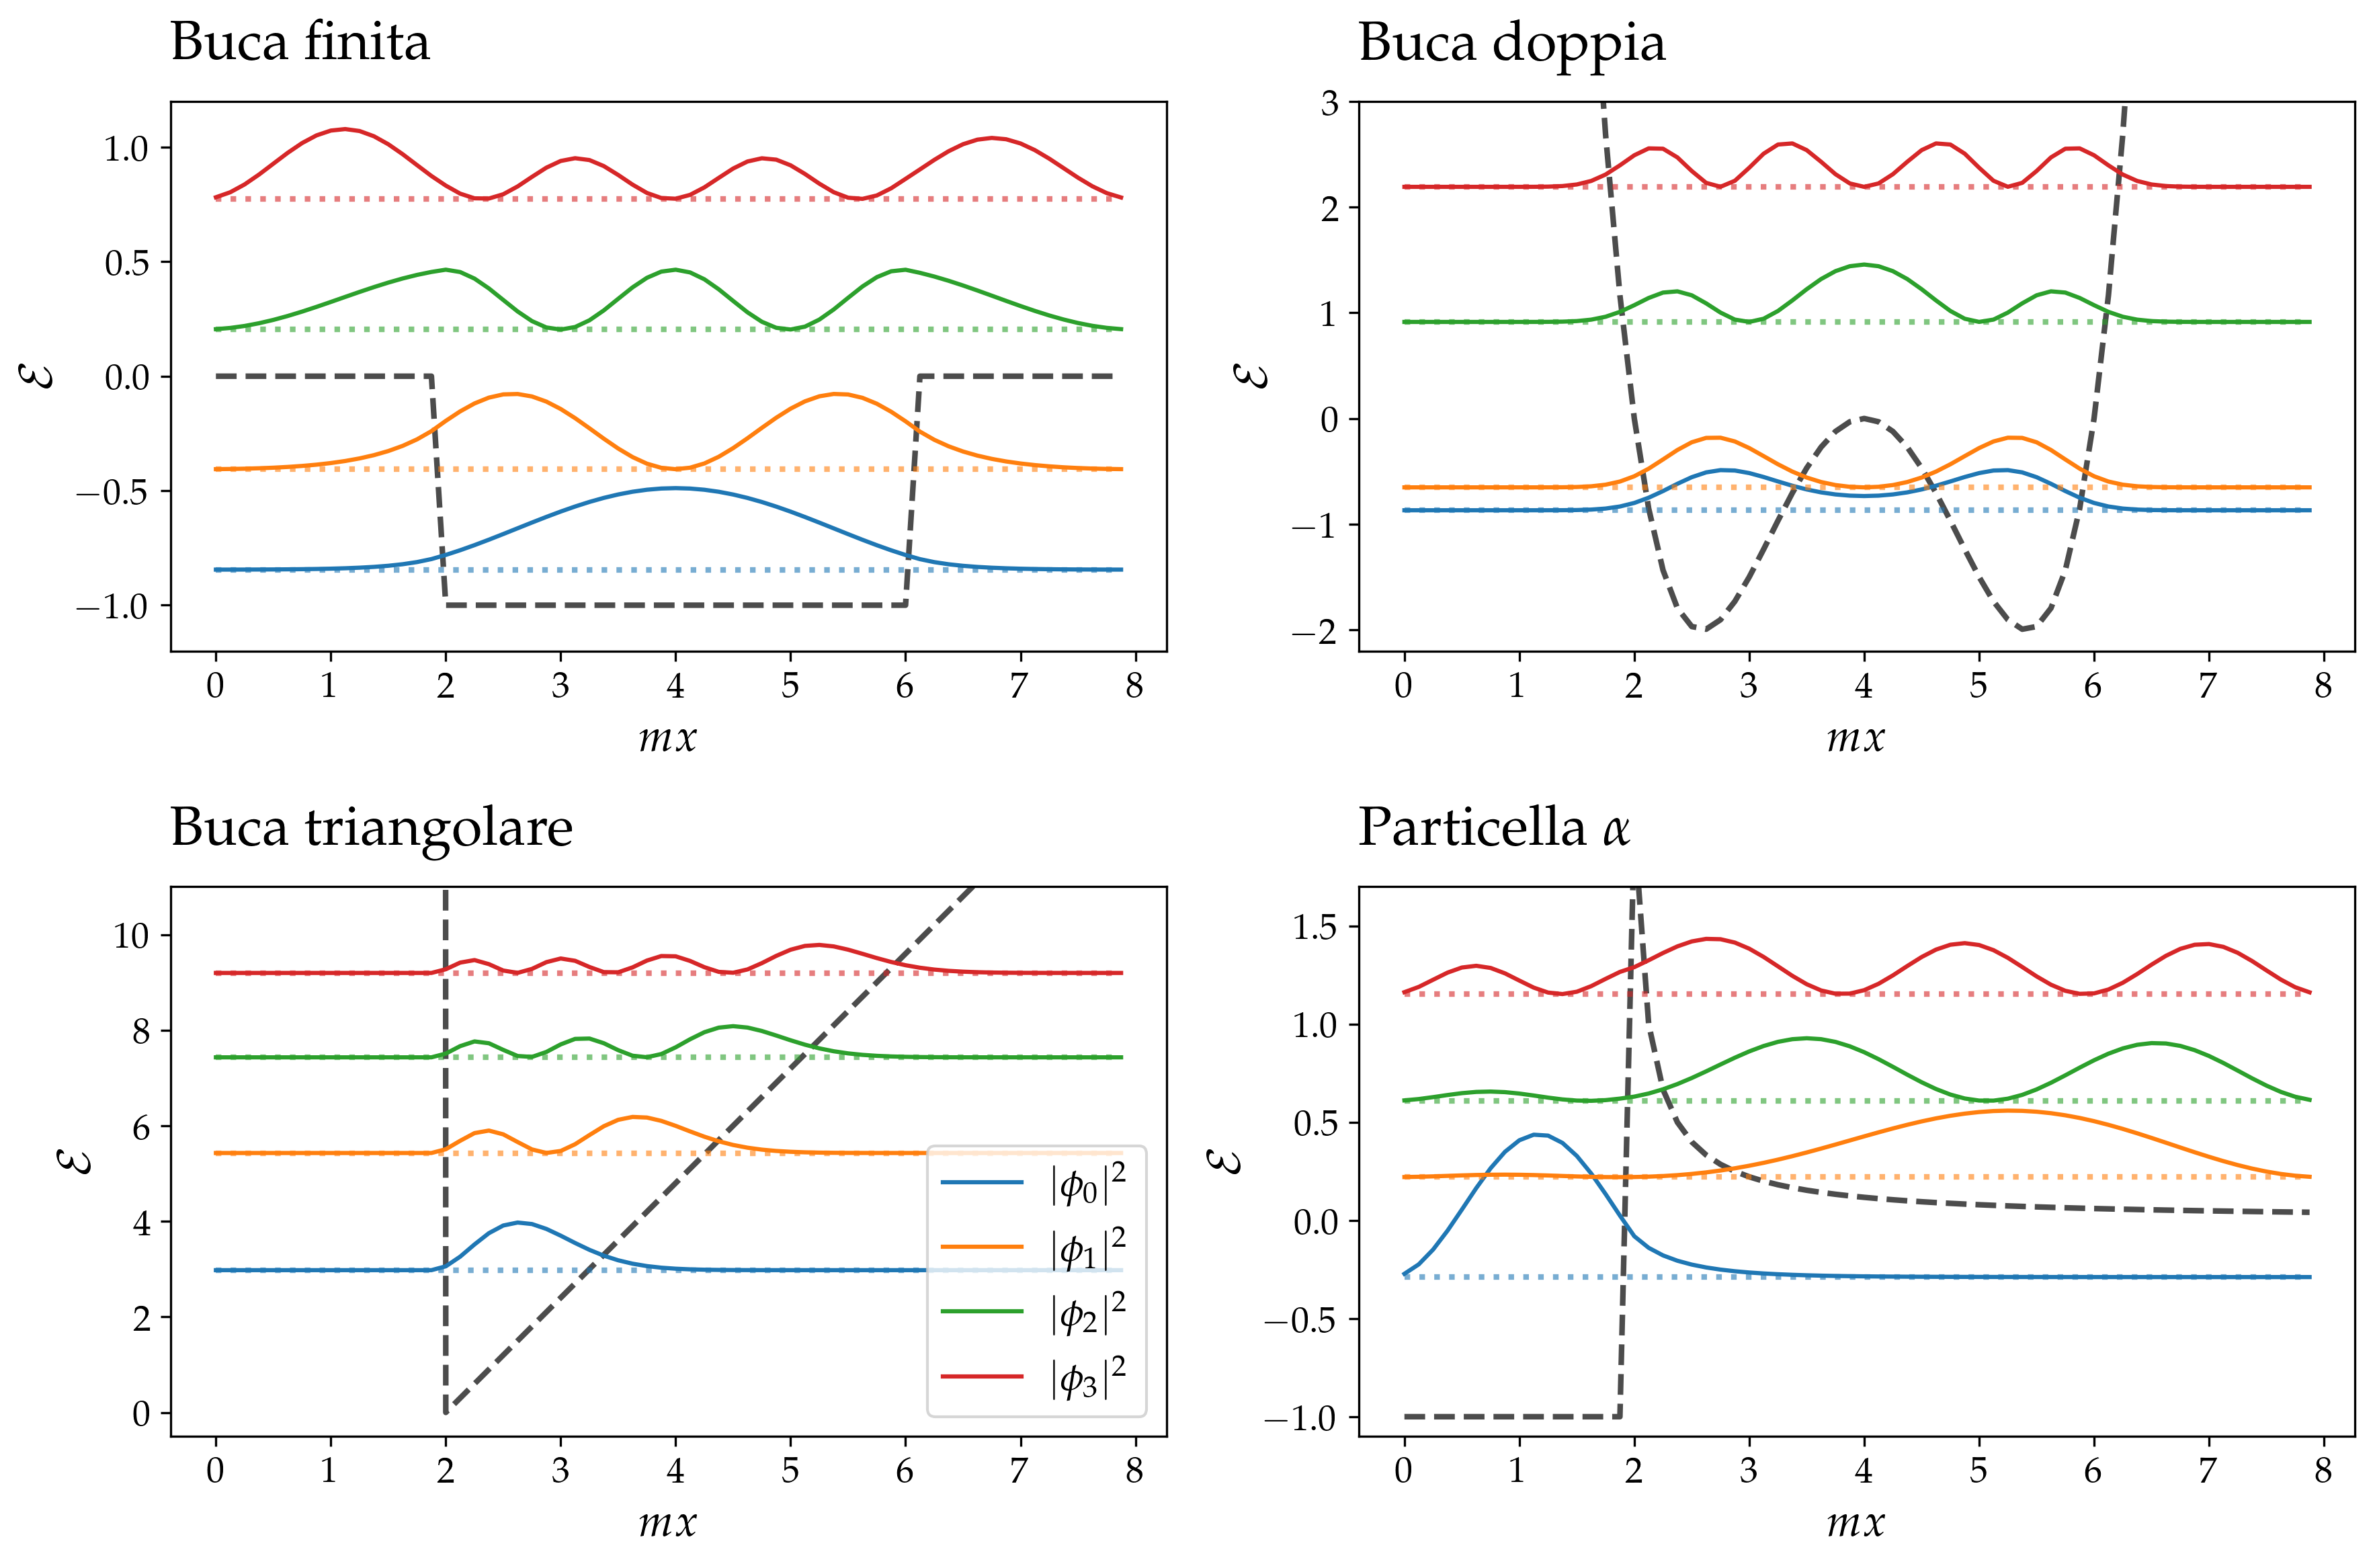

In [42]:
from data_diffV import N_points, mL, static_V_ls , names

tot_eig_val = np.load('txts/diff_val.npy')
tot_eig_vect = np.load('txts/diff_vect.npy')

selec = 4
eig_val = np.copy(tot_eig_val)[:, :selec]
eig_vect = np.copy(tot_eig_vect)[:, :, :selec]

cols = [f'C{i}' for i in range(10)]


names_ita = [
    'Buca finita',
	'Buca doppia',
	'Buca triangolare',
	r'Particella $\alpha$'
]

fig, ax = plt.subplots(2, 2, figsize=(12, 8))
ax = ax.flatten()

lims = [[-1.2, 1.2],
        [-2.2, 3],
        [-0.5, 11],
        [-1.1, 1.7]]

for k, StaticV in enumerate(static_V_ls):
	plt.sca(ax[k])
	eig_val_k = eig_val[k]
	eig_vect_k = eig_vect[k,:, :]
	eig_vect_k = eig_vect_k**2 * mL    # rescaling for plotting

	print(f'''\n-----------------------------------
	{names[k]}
-----------------------------------''')


	print('Eigenvalues =', eig_val_k)
	plt.plot(x_mL, StaticV(x_coo), color='black', ls='--', alpha=0.7, lw=2)
	for i, eig in enumerate(eig_val_k):
		vect =  eig_vect_k[:, i] + eig
		plt.hlines(eig, min(x_mL), max(x_mL), color=cols[i], ls=':', alpha=0.6, lw=2)
		plt.plot(x_mL, vect, color=cols[i], zorder=2,
				 label=rf'$|\phi_{i}|^2$')
		plt.title(names_ita[k],
            fontsize=20, 
            fontweight='bold', 
            loc='left',
            pad=15)
		plt.ylim(*lims[k])
		plt.xlabel(r'$mx$')
		plt.ylabel(r'$\mathcal{E}$')

	if k==2:
		plt.legend(loc='lower right')
	else:
		pass

plt.tight_layout()
plt.savefig('plots/comp_Vs.png')
plt.show()



-----------------------------------
	Finite well
-----------------------------------
Eigenvalues = [-0.84468613 -0.40611896  0.20371331  0.77382485]

-----------------------------------
	Double well
-----------------------------------
Eigenvalues = [-0.86839085 -0.65178488  0.91351048  2.19164673]

-----------------------------------
	Triangular well
-----------------------------------
Eigenvalues = [2.97710486 5.42871732 7.4308995  9.19669701]

-----------------------------------
	Alpha well
-----------------------------------
Eigenvalues = [-0.28858273  0.22054353  0.60922982  1.15316484]


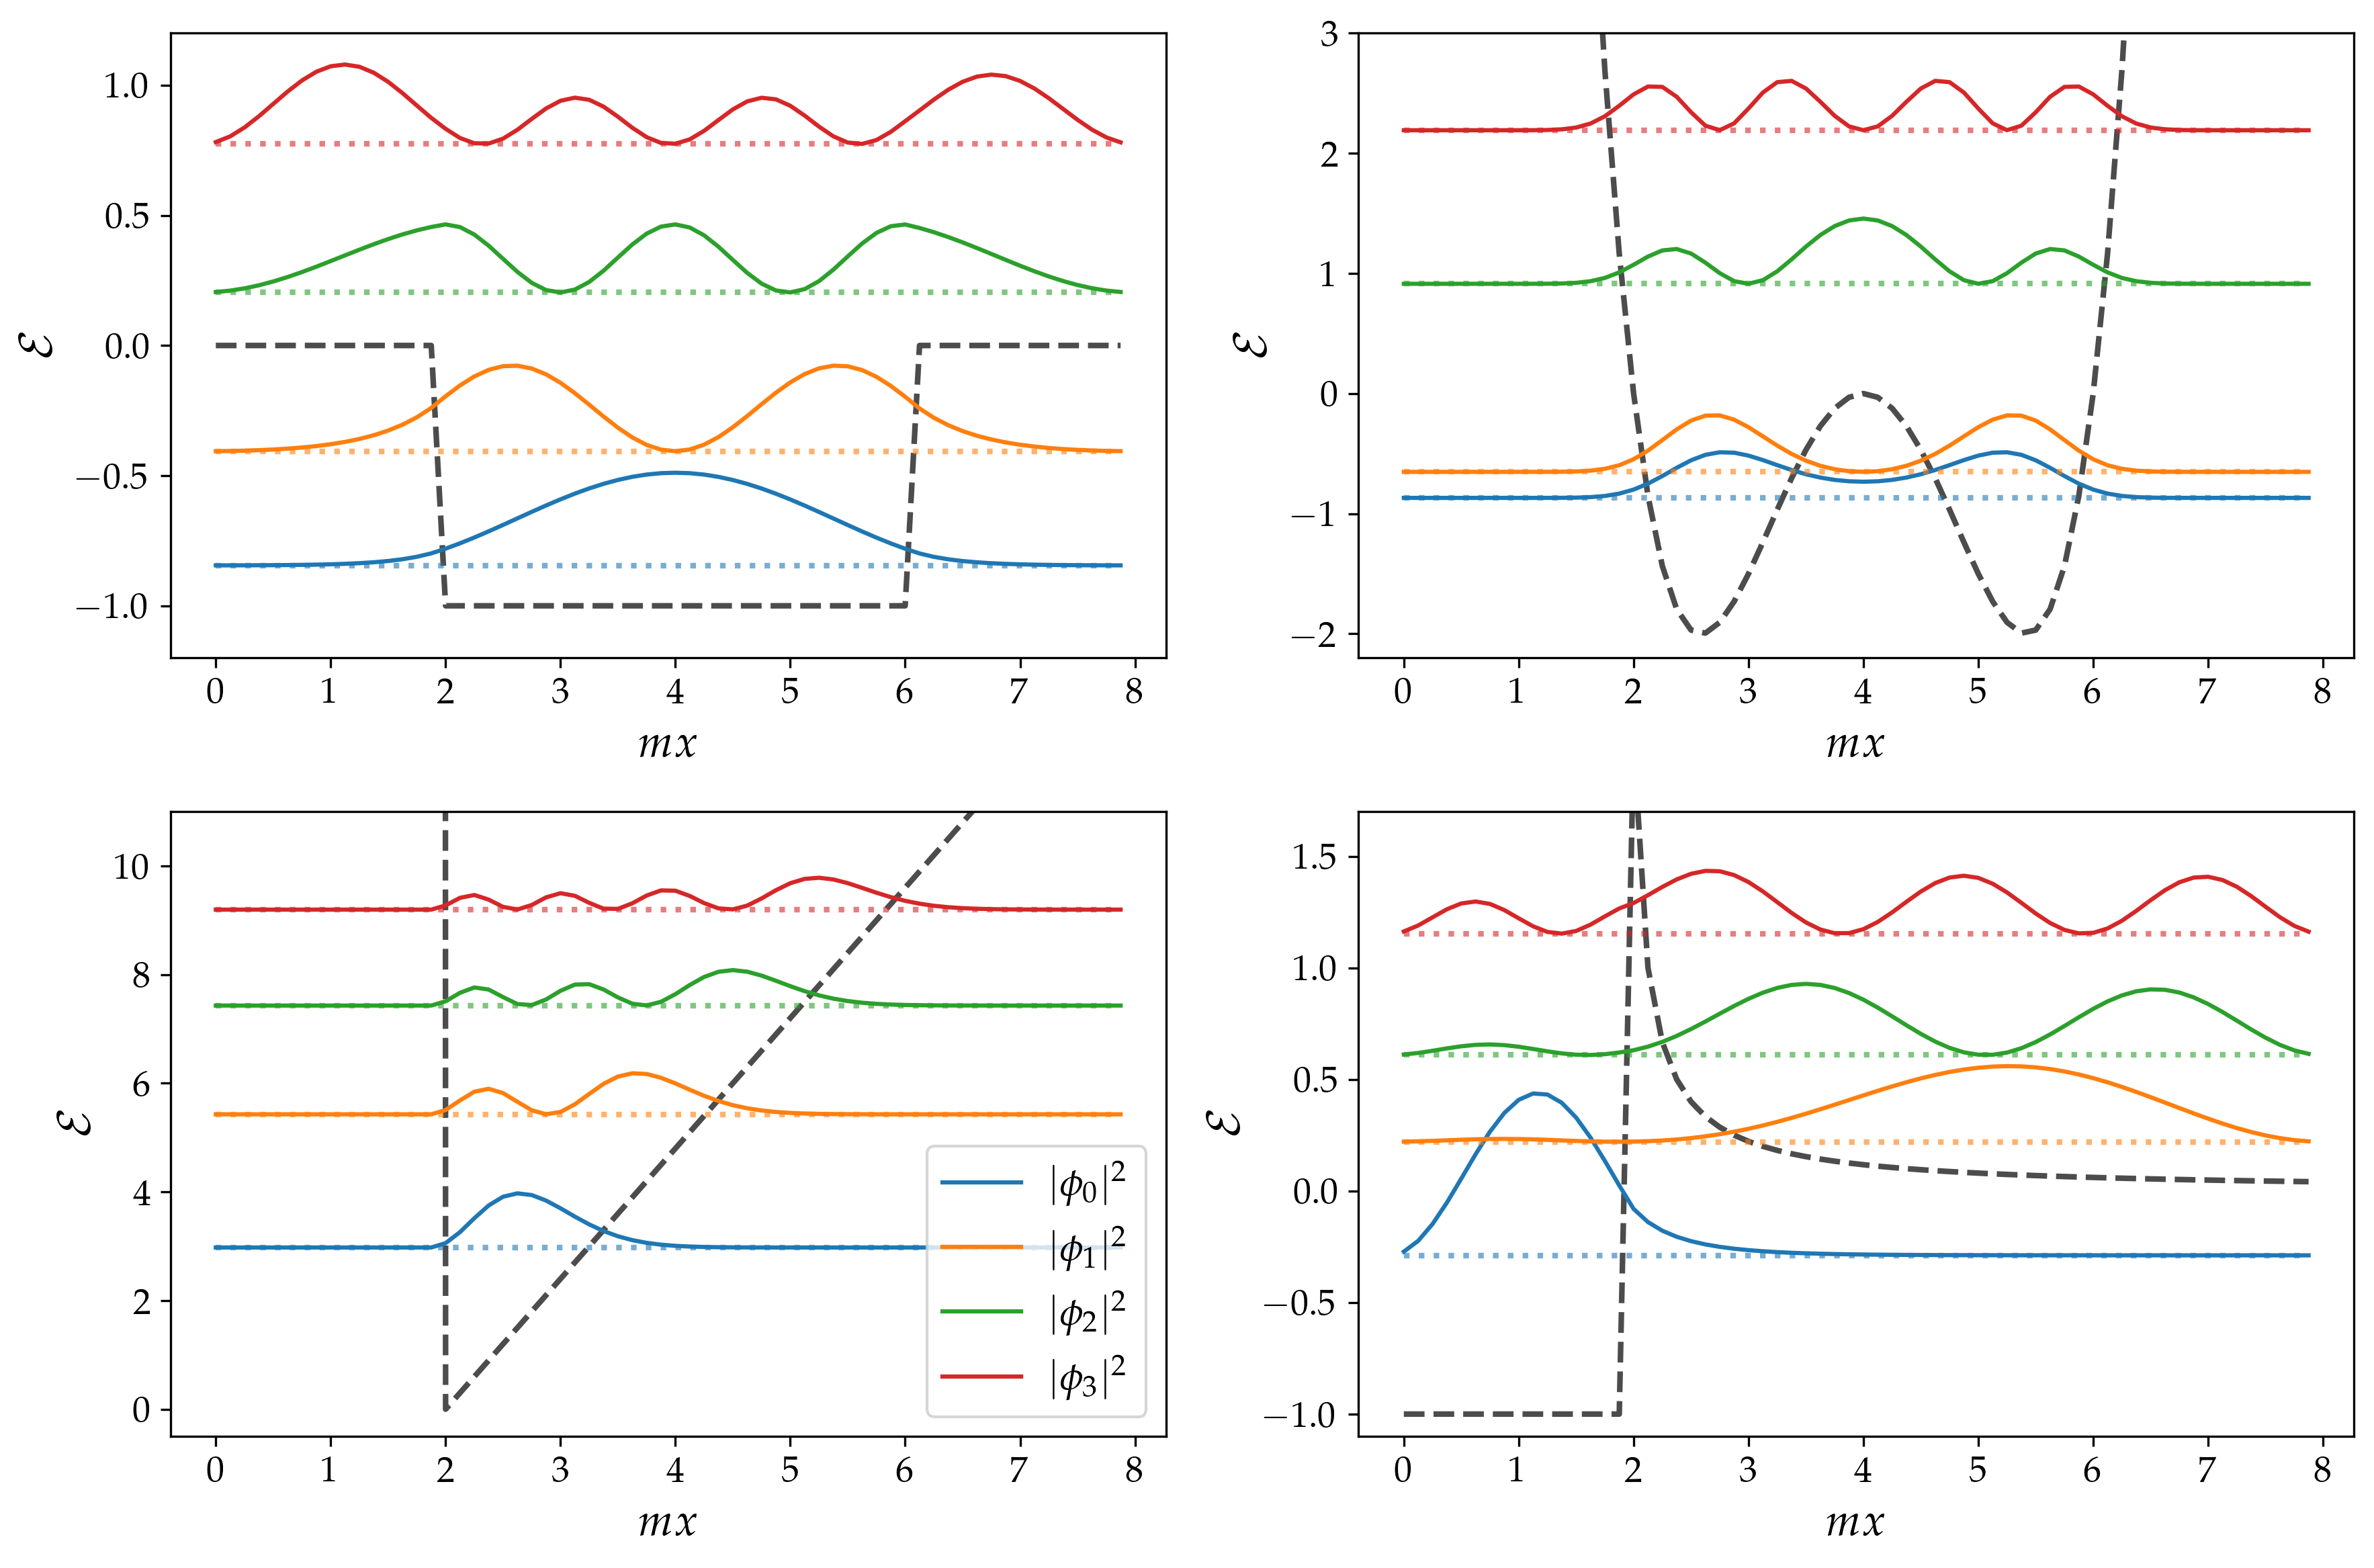

In [43]:
from data_diffV import N_points, mL, static_V_ls , names

tot_eig_val = np.load('txts/diff_val.npy')
tot_eig_vect = np.load('txts/diff_vect.npy')

selec = 4
eig_val = np.copy(tot_eig_val)[:, :selec]
eig_vect = np.copy(tot_eig_vect)[:, :, :selec]

cols = [f'C{i}' for i in range(10)]


names_ita = [
    'Buca finita',
	'Buca doppia',
	'Buca triangolare',
	r'Particella $\alpha$'
]

fig, ax = plt.subplots(2, 2, figsize=(12, 8))
ax = ax.flatten()

lims = [[-1.2, 1.2],
        [-2.2, 3],
        [-0.5, 11],
        [-1.1, 1.7]]

for k, StaticV in enumerate(static_V_ls):
	plt.sca(ax[k])
	eig_val_k = eig_val[k]
	eig_vect_k = eig_vect[k,:, :]
	eig_vect_k = eig_vect_k**2 * mL    # rescaling for plotting

	print(f'''\n-----------------------------------
	{names[k]}
-----------------------------------''')


	print('Eigenvalues =', eig_val_k)
	plt.plot(x_mL, StaticV(x_coo), color='black', ls='--', alpha=0.7, lw=2)
	for i, eig in enumerate(eig_val_k):
		vect =  eig_vect_k[:, i] + eig
		plt.hlines(eig, min(x_mL), max(x_mL), color=cols[i], ls=':', alpha=0.6, lw=2)
		plt.plot(x_mL, vect, color=cols[i], zorder=2,
				 label=rf'$|\phi_{i}|^2$')
		plt.ylim(*lims[k])
		plt.xlabel(r'$mx$')
		plt.ylabel(r'$\mathcal{E}$')

	if k==2:
		plt.legend(loc='lower right')
	else:
		pass

plt.tight_layout()
plt.savefig('plots/comp_Vs_noTitle.png')
plt.show()
